# LBPH Training & Evaluation

In [23]:
# === IMPORTS ===
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [24]:
# === CONFIGURATION ===

DATA_FOLDER               = os.path.join("..", "data")
AUGMENTED_FOLDER          = os.path.join(DATA_FOLDER, "augmented")
FINAL_PROCESSED_FOLDER    = os.path.join(DATA_FOLDER, "final_processed")
PREVIEW_FOLDER            = os.path.join(DATA_FOLDER, "preview")
PREVIEW_EVALUATION_FOLDER = os.path.join(PREVIEW_FOLDER, "evaluation_results")
MODELS_FOLDER             = os.path.join("..", "models")

OUTPUT_SIZE   = (128, 128)   # Must match the size used in ImageProcessingPipeline
IMAGE_QUALITY = 95           # JPG save quality

os.makedirs(PREVIEW_EVALUATION_FOLDER, exist_ok=True)
os.makedirs(MODELS_FOLDER, exist_ok=True)

print("Configuration loaded!")
print(f"   AUGMENTED_FOLDER:       {AUGMENTED_FOLDER}")
print(f"   FINAL_PROCESSED_FOLDER: {FINAL_PROCESSED_FOLDER}")
print(f"   MODELS_FOLDER:          {MODELS_FOLDER}")
print(f"   OUTPUT_SIZE:            {OUTPUT_SIZE}")


Configuration loaded!
   AUGMENTED_FOLDER:       ..\data\augmented
   FINAL_PROCESSED_FOLDER: ..\data\final_processed
   MODELS_FOLDER:          ..\models
   OUTPUT_SIZE:            (128, 128)


# Prepare Training Data

In [ ]:
def prepare_training_data(source_folder=None, test_ratio=0.2, random_seed=42, use_augmented=True):
    """
    Load face crops and split into training/testing sets with NO data leakage.

    Strategy:
      1. Identify original images (no '_faug_' / '_aug_' in filename).
      2. Split originals per-person into train_orig and test_orig using test_ratio.
      3. Find augmented files derived from train_orig only
         (aug filename starts with the original stem → match via '_faug_' / '_aug_' marker).
      4. Train set = train_orig + (augmented from train_orig, if use_augmented=True)
         Test  set = test_orig only — never contaminated by augmentation.

    Args:
        source_folder:  Per-person subfolders (default: AUGMENTED_FOLDER)
        test_ratio:     Fraction of original images held out for testing
        random_seed:    Seed for reproducible per-person splits
        use_augmented:  Include augmented images in train set (True) or not (False)
    """
    if source_folder is None:
        source_folder = AUGMENTED_FOLDER

    print("PREPARING TRAINING DATASET")
    print("=" * 55)
    print(f"  Source:        {source_folder}")
    print(f"  Use augmented: {use_augmented}")
    print(f"  Test ratio:    {test_ratio} (original images only — no leakage)\n")

    if not os.path.exists(source_folder):
        print(f"[X] Source folder not found: {source_folder}")
        print("   Run face crop augmentation first (Step 5b).")
        return None

    person_dirs = sorted([
        d for d in os.listdir(source_folder)
        if os.path.isdir(os.path.join(source_folder, d))
    ])

    if not person_dirs:
        print("[X] No person folders found!")
        return None

    print(f"Loading face crops from {len(person_dirs)} people...\n")

    label_names = []
    label_map   = {}
    X_train, y_train = [], []
    X_test,  y_test  = [], []

    def aug_source_stem(aug_filename):
        """Return the original image stem an augmented file was derived from."""
        for marker in ('_faug_', '_aug_'):
            if marker in aug_filename:
                return aug_filename.split(marker)[0]
        return None

    def load_imgs(file_list, person_path, label):
        imgs, lbls = [], []
        for f in file_list:
            img = cv2.imread(os.path.join(person_path, f), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                if img.shape != OUTPUT_SIZE:
                    img = cv2.resize(img, OUTPUT_SIZE)
                imgs.append(img)
                lbls.append(label)
        return imgs, lbls

    for label_id, person_name in enumerate(person_dirs):
        person_path = os.path.join(source_folder, person_name)
        label_map[person_name] = label_id
        label_names.append(person_name)

        all_files = sorted([
            f for f in os.listdir(person_path)
            if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}
        ])

        # Separate originals from augmented variants
        original_files  = [f for f in all_files if '_faug_' not in f and '_aug_' not in f]
        augmented_files = [f for f in all_files if '_faug_' in f or '_aug_' in f]

        if not original_files:
            print(f"  [!] {person_name}: no original images — skipped")
            continue

        # Per-person reproducible shuffle → split originals into test / train
        rng = np.random.RandomState(random_seed + label_id)
        shuffled = original_files.copy()
        rng.shuffle(shuffled)

        n_test     = max(1, round(len(shuffled) * test_ratio))
        test_orig  = shuffled[:n_test]
        train_orig = shuffled[n_test:]

        # Augmented files that came from test originals must NEVER enter train
        test_stems = {Path(f).stem for f in test_orig}
        if use_augmented:
            train_aug = [f for f in augmented_files
                         if aug_source_stem(f) not in test_stems]
        else:
            train_aug = []

        train_files = train_orig + train_aug

        tr_imgs, tr_lbls = load_imgs(train_files, person_path, label_id)
        te_imgs, te_lbls = load_imgs(test_orig,   person_path, label_id)

        X_train.extend(tr_imgs); y_train.extend(tr_lbls)
        X_test.extend(te_imgs);  y_test.extend(te_lbls)

        print(f"  {person_name}: train={len(tr_imgs)} "
              f"({len(train_orig)} orig + {len(train_aug)} aug), "
              f"test={len(te_imgs)} orig-only  [label={label_id}]")

    if not X_train or not X_test:
        print("[X] Not enough images to build train/test sets!")
        return None

    X_train = np.array(X_train)
    X_test  = np.array(X_test)
    y_train = np.array(y_train)
    y_test  = np.array(y_test)

    stats = {
        "total_people":      len(label_names),
        "train_size":        len(X_train),
        "test_size":         len(X_test),
        "images_per_person": {
            p: int(np.sum(y_train == label_map[p]) + np.sum(y_test == label_map[p]))
            for p in label_names
        },
    }

    print(f"\nDATASET SPLIT:")
    print(f"  Training set: {len(X_train)} images (orig + aug, leakage-free)")
    print(f"  Testing set:  {len(X_test)} images (original only — no data leakage)")
    print(f"  People:       {len(label_names)}")
    print(f"  Image size:   {OUTPUT_SIZE}")
    print(f"\n[OK] Training data ready!")

    return {
        "X_train":     X_train,
        "X_test":      X_test,
        "y_train":     y_train,
        "y_test":      y_test,
        "label_names": label_names,
        "label_map":   label_map,
        "stats":       stats,
    }

# Prepare training dataset (default: augmented folder, use_augmented=True)
training_data = prepare_training_data()

PREPARING TRAINING DATASET
Loading face crops from 18 people...

  Dr.Nurul: 100 face crops (label=0)
  benjamin: 200 face crops (label=1)
  chern_tak: 200 face crops (label=2)
  chillien: 200 face crops (label=3)
  daniel: 200 face crops (label=4)
  dylan: 100 face crops (label=5)
  han_soon: 200 face crops (label=6)
  harry: 200 face crops (label=7)
  kang_kai: 200 face crops (label=8)
  marion: 0 face crops (label=9)
  qi_xuan: 200 face crops (label=10)
  shuang_quan: 200 face crops (label=11)
  wee_xuan: 200 face crops (label=12)
  xiang_yue: 200 face crops (label=13)
  xu_sheng: 200 face crops (label=14)
  yoke_hong: 200 face crops (label=15)
  yong_kang: 200 face crops (label=16)
  zi_herng: 200 face crops (label=17)

Dataset loaded: 3200 images, 18 people

DATASET SPLIT:
  Training set: 2560 images (80%)
  Testing set:  640 images (20%)
  People:       18
  Image size:   (128, 128)

  Per-person breakdown:
    Dr.Nurul: 80 train + 20 test
    benjamin: 160 train + 40 test
    ch

# Train LBPH model

In [ ]:
def train_lbph_model(training_data, save_path=None,
                     radius=1, neighbors=8, grid_x=8, grid_y=8):
    """
    Train an LBPH face recognizer using the prepared training data.
    """
    if training_data is None:
        print("[X] No training data provided!")
        return None
    
    if save_path is None:
        save_path = os.path.join(MODELS_FOLDER, "lbph_model.yml")
    
    print("TRAINING LBPH FACE RECOGNIZER")
    print("=" * 55)
    print(f"  Image size:  {OUTPUT_SIZE}")
    print(f"  Parameters:  radius={radius}, neighbors={neighbors}, grid=({grid_x}x{grid_y})")
    print(f"  Training on: {len(training_data['X_train'])} images")
    print(f"  Testing on:  {len(training_data['X_test'])} images")
    print(f"  People:      {len(training_data['label_names'])}\n")
    
    # Create LBPH recognizer
    model = cv2.face.LBPHFaceRecognizer_create(
        radius=radius,
        neighbors=neighbors, 
        grid_x=grid_x,
        grid_y=grid_y
    )
    
    # Train
    print("Training model...")
    start_time = time.time()
    
    X_train = list(training_data["X_train"])
    y_train = training_data["y_train"].astype(np.int32)
    model.train(X_train, y_train)
    
    train_time = time.time() - start_time
    print(f"[OK] Training complete in {train_time:.2f}s")
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    X_test = training_data["X_test"]
    y_test = training_data["y_test"]
    label_names = training_data["label_names"]
    
    predictions = []
    confidences = []
    correct = 0
    
    for i in range(len(X_test)):
        pred_label, confidence = model.predict(X_test[i])
        predictions.append(pred_label)
        confidences.append(confidence)
        if pred_label == y_test[i]:
            correct += 1
    
    accuracy = correct / len(y_test) * 100 if len(y_test) > 0 else 0
    predictions = np.array(predictions)
    confidences = np.array(confidences)
    
    # Per-person accuracy
    print(f"\nEVALUATION RESULTS:")
    print(f"{'─' * 55}")
    print(f"  Overall accuracy: {accuracy:.1f}% ({correct}/{len(y_test)})")
    print(f"  Mean confidence:  {np.mean(confidences):.1f} (lower = better)")
    print(f"  Training time:    {train_time:.2f}s")
    
    print(f"\n  Per-person accuracy:")
    per_person_acc = {}
    for lid, person_name in enumerate(label_names):
        mask = y_test == lid
        if np.sum(mask) > 0:
            person_correct = np.sum(predictions[mask] == lid)
            person_total = np.sum(mask)
            person_acc = person_correct / person_total * 100
            per_person_acc[person_name] = person_acc
            status = "[OK]" if person_acc >= 80 else ("[!]" if person_acc >= 50 else "[X]")
            print(f"    {status} {person_name}: {person_acc:.0f}% ({person_correct}/{person_total})")
    
    # Save model
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save(save_path)
    print(f"\nModel saved: {save_path}")
    
    # Save label mapping
    label_map_path = os.path.join(os.path.dirname(save_path), "label_map.txt")
    with open(label_map_path, "w") as f:
        for lid, name in enumerate(label_names):
            f.write(f"{lid},{name}\n")
    print(f"Label map saved: {label_map_path}")
    
    result = {
        "model": model,
        "accuracy": accuracy,
        "predictions": predictions,
        "confidences": confidences,
        "y_test": y_test,
        "label_names": label_names,
        "per_person_acc": per_person_acc,
        "train_time": train_time,
        "save_path": save_path,
    }
    
    return result

# Train LBPH model
lbph_result = train_lbph_model(training_data)


TRAINING LBPH FACE RECOGNIZER
  Image size:  (128, 128)
  Parameters:  radius=1, neighbors=8, grid=(8x8)
  Training on: 2560 images
  Testing on:  640 images
  People:      18

Training model...
[OK] Training complete in 3.31s

Evaluating on test set...

EVALUATION RESULTS:
───────────────────────────────────────────────────────
  Overall accuracy: 95.0% (608/640)
  Mean confidence:  35.5 (lower = better)
  Training time:    3.31s

  Per-person accuracy:
    [OK] Dr.Nurul: 100% (20/20)
    [OK] benjamin: 85% (34/40)
    [OK] chern_tak: 95% (38/40)
    [OK] chillien: 100% (40/40)
    [OK] daniel: 92% (37/40)
    [OK] dylan: 100% (20/20)
    [OK] han_soon: 100% (40/40)
    [OK] harry: 82% (33/40)
    [OK] kang_kai: 98% (39/40)
    [OK] qi_xuan: 100% (40/40)
    [OK] shuang_quan: 90% (36/40)
    [OK] wee_xuan: 100% (40/40)
    [OK] xiang_yue: 98% (39/40)
    [OK] xu_sheng: 95% (38/40)
    [OK] yoke_hong: 95% (38/40)
    [OK] yong_kang: 90% (36/40)
    [OK] zi_herng: 100% (40/40)

Model sa

# Model Evaluation: Confusion Matrix & Augmentation Impact

Plotting LBPH model evaluation...

Evaluation plot saved: ..\data\preview\evaluation_results\lbph_evaluation.png


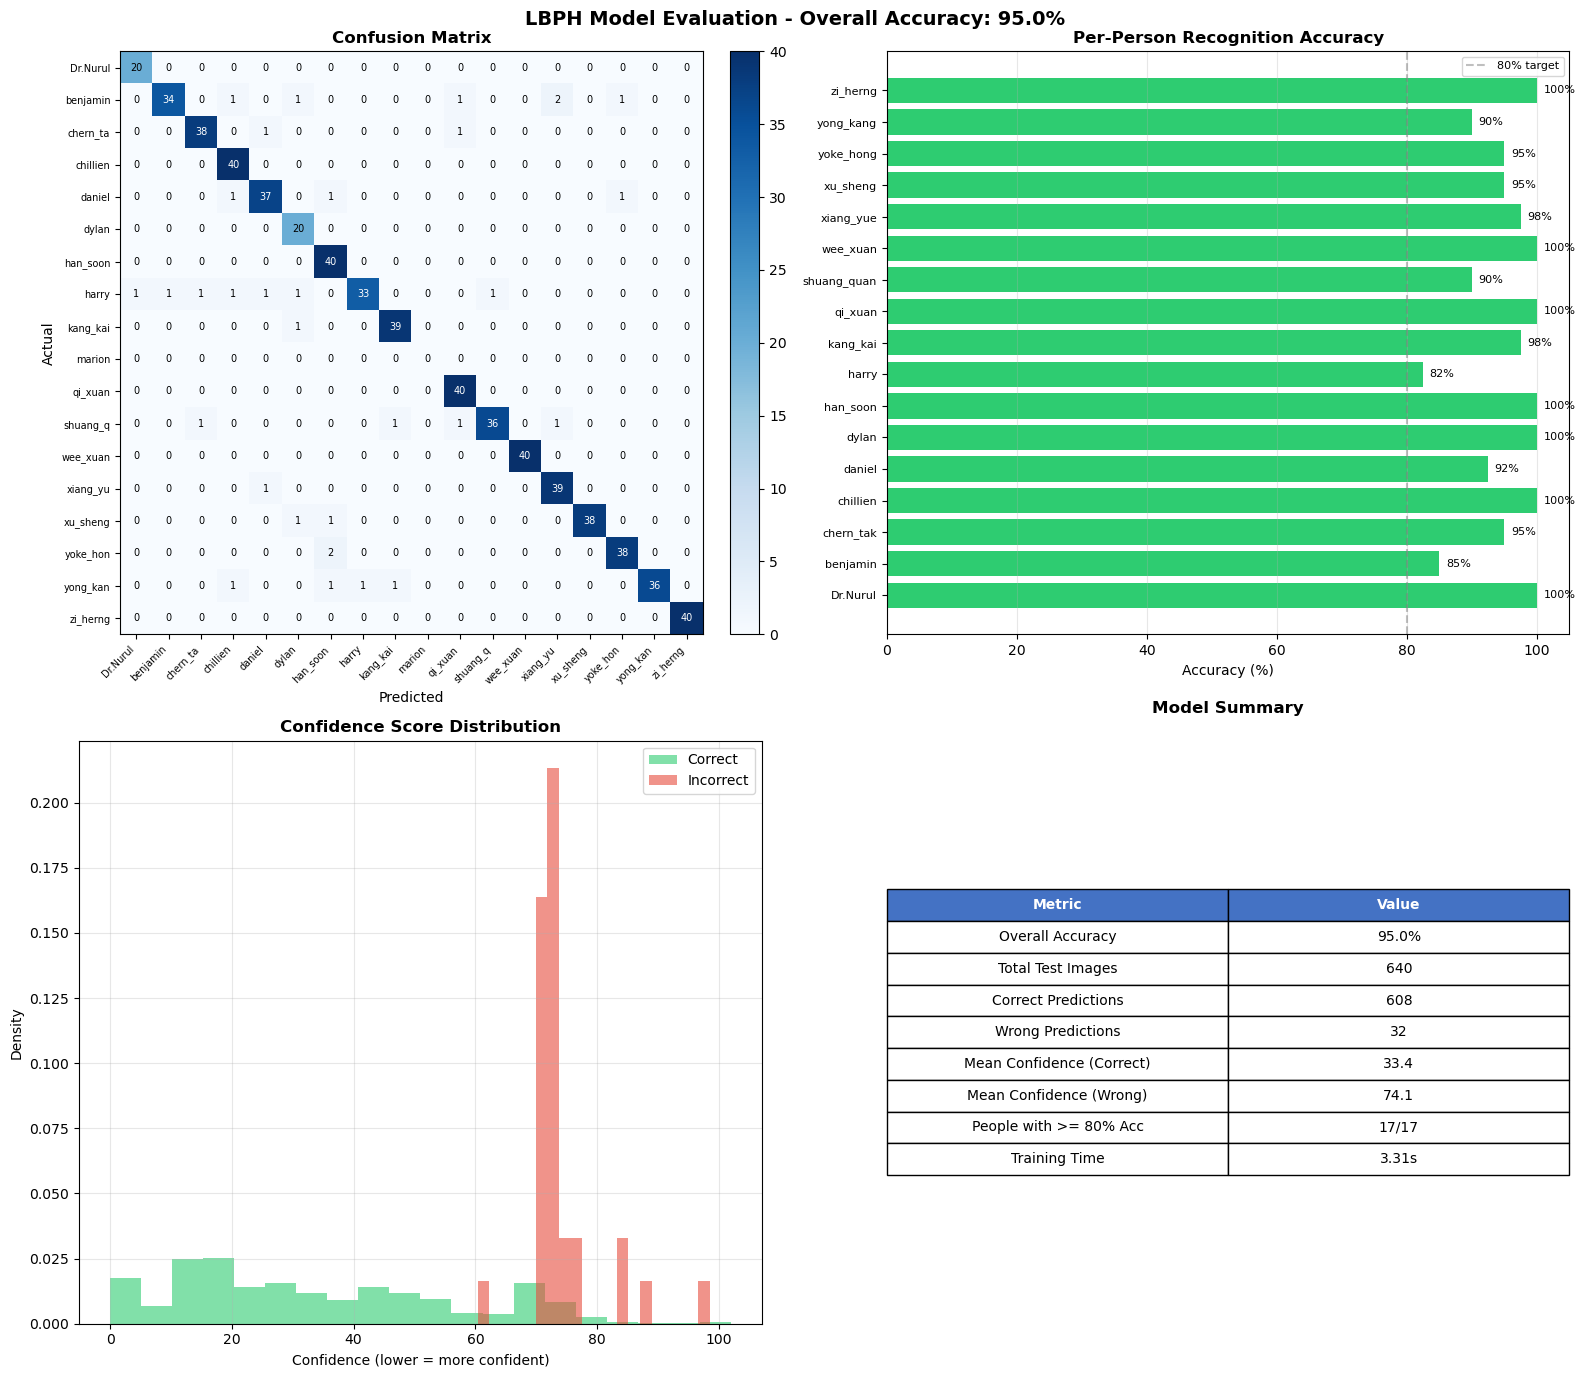


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Dr.Nurul       0.95      1.00      0.98        20
    benjamin       0.97      0.85      0.91        40
   chern_tak       0.95      0.95      0.95        40
    chillien       0.91      1.00      0.95        40
      daniel       0.93      0.93      0.93        40
       dylan       0.83      1.00      0.91        20
    han_soon       0.89      1.00      0.94        40
       harry       0.97      0.82      0.89        40
    kang_kai       0.95      0.97      0.96        40
     qi_xuan       0.93      1.00      0.96        40
 shuang_quan       0.97      0.90      0.94        40
    wee_xuan       1.00      1.00      1.00        40
   xiang_yue       0.93      0.97      0.95        40
    xu_sheng       1.00      0.95      0.97        40
   yoke_hong       0.95      0.95      0.95        40
   yong_kang       1.00      0.90      0.95        40
    zi_herng       1.00      1.00      1.00        40

  

In [ ]:
def plot_evaluation(lbph_result, save_dir=None):
    """
    Plot confusion matrix and per-person accuracy for LBPH model.
    
    Args:
        lbph_result: Dict returned by train_lbph_model()
        save_dir: Directory to save plots (default: PREVIEW_EVALUATION_FOLDER)
    """
    if lbph_result is None:
        print("[X] No model results to plot.")
        return
    
    if save_dir is None:
        save_dir = PREVIEW_EVALUATION_FOLDER
    os.makedirs(save_dir, exist_ok=True)
    
    y_test = lbph_result["y_test"]
    predictions = lbph_result["predictions"]
    confidences = lbph_result["confidences"]
    label_names = lbph_result["label_names"]
    per_person_acc = lbph_result["per_person_acc"]
    accuracy = lbph_result["accuracy"]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f"LBPH Model Evaluation - Overall Accuracy: {accuracy:.1f}%", 
                 fontsize=14, fontweight='bold')
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, predictions, labels=list(range(len(label_names))))
    im = axes[0, 0].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[0, 0].set_title("Confusion Matrix", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Predicted")
    axes[0, 0].set_ylabel("Actual")
    
    short_names = [n[:8] for n in label_names]
    tick_positions = list(range(len(label_names)))
    axes[0, 0].set_xticks(tick_positions)
    axes[0, 0].set_yticks(tick_positions)
    axes[0, 0].set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
    axes[0, 0].set_yticklabels(short_names, fontsize=7)
    
    thresh = cm.max() / 2.0
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            color = "white" if cm[i, j] > thresh else "black"
            axes[0, 0].text(j, i, str(cm[i, j]), ha="center", va="center", 
                           color=color, fontsize=7)
    
    fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)
    
    # 2. Per-Person Accuracy Bar Chart
    persons = list(per_person_acc.keys())
    accs = [per_person_acc[p] for p in persons]
    
    colors = ['#2ecc71' if a >= 80 else ('#f39c12' if a >= 50 else '#e74c3c') for a in accs]
    bars = axes[0, 1].barh(range(len(persons)), accs, color=colors)
    axes[0, 1].set_yticks(range(len(persons)))
    axes[0, 1].set_yticklabels([p[:12] for p in persons], fontsize=8)
    axes[0, 1].set_xlabel("Accuracy (%)")
    axes[0, 1].set_title("Per-Person Recognition Accuracy", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlim(0, 105)
    axes[0, 1].axvline(x=80, color='gray', linestyle='--', alpha=0.5, label='80% target')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    for bar, acc in zip(bars, accs):
        axes[0, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                        f'{acc:.0f}%', va='center', fontsize=8)
    
    # 3. Confidence Distribution
    correct_mask = predictions == y_test
    if np.sum(correct_mask) > 0:
        axes[1, 0].hist(confidences[correct_mask], bins=20, alpha=0.6, 
                        color='#2ecc71', label='Correct', density=True)
    if np.sum(~correct_mask) > 0:
        axes[1, 0].hist(confidences[~correct_mask], bins=20, alpha=0.6, 
                        color='#e74c3c', label='Incorrect', density=True)
    axes[1, 0].set_title("Confidence Score Distribution", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Confidence (lower = more confident)")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Summary Table
    axes[1, 1].axis('off')
    summary_data = [
        ["Metric", "Value"],
        ["Overall Accuracy", f"{accuracy:.1f}%"],
        ["Total Test Images", f"{len(y_test)}"],
        ["Correct Predictions", f"{int(np.sum(correct_mask))}"],
        ["Wrong Predictions", f"{int(np.sum(~correct_mask))}"],
        ["Mean Confidence (Correct)", f"{np.mean(confidences[correct_mask]):.1f}" if np.sum(correct_mask) > 0 else "N/A"],
        ["Mean Confidence (Wrong)", f"{np.mean(confidences[~correct_mask]):.1f}" if np.sum(~correct_mask) > 0 else "N/A"],
        ["People with >= 80% Acc", f"{sum(1 for a in accs if a >= 80)}/{len(accs)}"],
        ["Training Time", f"{lbph_result['train_time']:.2f}s"],
    ]
    
    table = axes[1, 1].table(cellText=summary_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.6)
    for j in range(2):
        table[0, j].set_facecolor('#4472C4')
        table[0, j].set_text_props(color='white', fontweight='bold')
    axes[1, 1].set_title("Model Summary", fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    eval_path = os.path.join(save_dir, "lbph_evaluation.png")
    fig.savefig(eval_path, dpi=150, bbox_inches='tight')
    print(f"Evaluation plot saved: {eval_path}")
    plt.show()
    
    # Only include labels that actually appear in y_test (some people may have
    # too few images to appear in the stratified test split)
    present_labels = sorted(set(y_test))
    present_names  = [label_names[i][:12] for i in present_labels]
    print(f"\nCLASSIFICATION REPORT:")
    print(classification_report(y_test, predictions,
                                labels=present_labels,
                                target_names=present_names,
                                zero_division=0))


def compare_augmentation_impact(test_ratio=0.2, random_seed=42):
    """
    Compare LBPH accuracy trained WITH vs WITHOUT augmentation.
    
    - Without: trains on original face crops only (from final_processed/)
    - With: trains on original + augmented face crops (from augmented/)
    """
    print("AUGMENTATION IMPACT COMPARISON")
    print("=" * 55)
    
    if not os.path.exists(FINAL_PROCESSED_FOLDER):
        print(f"[X] final_processed/ not found. Run the pipeline first.")
        return None
    if not os.path.exists(AUGMENTED_FOLDER):
        print(f"[X] augmented/ not found. Run face crop augmentation first.")
        return None
    
    # === Train WITHOUT augmentation ===
    print("\n" + "-" * 55)
    print("TRAINING WITHOUT AUGMENTATION (original face crops only)")
    print("-" * 55)
    
    data_no_aug = prepare_training_data(
        source_folder=AUGMENTED_FOLDER,
        test_ratio=test_ratio,
        random_seed=random_seed,
        use_augmented=False   
    )
    if data_no_aug is None:
        print("[X] Cannot prepare non-augmented data.")
        return None
    
    result_no_aug = train_lbph_model(
        data_no_aug, 
        save_path=os.path.join(MODELS_FOLDER, "lbph_no_augmentation.yml")
    )
    
    # === Train WITH augmentation ===
    print("\n" + "-" * 55)
    print("TRAINING WITH AUGMENTATION (original + augmented)")
    print("-" * 55)
    
    data_with_aug = prepare_training_data(
        source_folder=AUGMENTED_FOLDER,
        test_ratio=test_ratio,
        random_seed=random_seed,
        use_augmented=True    
    )
    
    if data_with_aug is None:
        print("[X] Cannot prepare augmented data.")
        return None
    
    result_with_aug = train_lbph_model(
        data_with_aug,
        save_path=os.path.join(MODELS_FOLDER, "lbph_with_augmentation.yml")
    )
    
    if result_no_aug is None or result_with_aug is None:
        print("[X] Training failed for one or both models.")
        return None
    
    # === Comparison Visualization ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Augmentation Impact on LBPH Recognition Accuracy", 
                 fontsize=14, fontweight='bold')
    
    # 1. Overall accuracy comparison
    categories = ['Without\nAugmentation', 'With\nAugmentation']
    accs = [result_no_aug['accuracy'], result_with_aug['accuracy']]
    colors = ['#3498db', '#2ecc71']
    bars = axes[0].bar(categories, accs, color=colors, width=0.5)
    axes[0].set_ylabel("Overall Accuracy (%)")
    axes[0].set_title("Overall Accuracy Comparison")
    axes[0].set_ylim(0, 105)
    for bar, acc in zip(bars, accs):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # 2. Per-person accuracy comparison
    common_persons = sorted(set(result_no_aug['per_person_acc'].keys()) & 
                           set(result_with_aug['per_person_acc'].keys()))
    
    if common_persons:
        x = np.arange(len(common_persons))
        width = 0.35
        
        acc_no = [result_no_aug['per_person_acc'].get(p, 0) for p in common_persons]
        acc_with = [result_with_aug['per_person_acc'].get(p, 0) for p in common_persons]
        
        axes[1].barh(x - width/2, acc_no, width, label='Without Aug', color='#3498db', alpha=0.8)
        axes[1].barh(x + width/2, acc_with, width, label='With Aug', color='#2ecc71', alpha=0.8)
        axes[1].set_yticks(x)
        axes[1].set_yticklabels([p[:10] for p in common_persons], fontsize=8)
        axes[1].set_xlabel("Accuracy (%)")
        axes[1].set_title("Per-Person Accuracy Comparison")
        axes[1].legend()
        axes[1].set_xlim(0, 105)
        axes[1].grid(True, alpha=0.3, axis='x')
    
    # 3. Summary metrics
    axes[2].axis('off')
    improvement = result_with_aug['accuracy'] - result_no_aug['accuracy']
    imp_symbol = "(+)" if improvement > 0 else ("(-)" if improvement < 0 else "(=)")
    
    comp_data = [
        ["Metric", "Without Aug", "With Aug"],
        ["Overall Accuracy", f"{result_no_aug['accuracy']:.1f}%", f"{result_with_aug['accuracy']:.1f}%"],
        ["Training Images", f"{data_no_aug['stats']['train_size']}", f"{data_with_aug['stats']['train_size']}"],
        ["Test Images", f"{data_no_aug['stats']['test_size']}", f"{data_with_aug['stats']['test_size']}"],
        ["Mean Confidence", f"{np.mean(result_no_aug['confidences']):.1f}", 
         f"{np.mean(result_with_aug['confidences']):.1f}"],
        ["Training Time", f"{result_no_aug['train_time']:.2f}s", f"{result_with_aug['train_time']:.2f}s"],
        [f"{imp_symbol} Improvement", "", f"{improvement:+.1f}%"],
    ]
    
    table = axes[2].table(cellText=comp_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.6)
    for j in range(3):
        table[0, j].set_facecolor('#4472C4')
        table[0, j].set_text_props(color='white', fontweight='bold')
    
    imp_color = '#d4edda' if improvement > 0 else ('#f8d7da' if improvement < 0 else '#fff3cd')
    for j in range(3):
        table[len(comp_data)-1, j].set_facecolor(imp_color)
    
    axes[2].set_title("Comparison Summary", fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    os.makedirs(PREVIEW_EVALUATION_FOLDER, exist_ok=True)
    comp_path = os.path.join(PREVIEW_EVALUATION_FOLDER, "augmentation_impact_comparison.png")
    fig.savefig(comp_path, dpi=150, bbox_inches='tight')
    print(f"\nComparison saved: {comp_path}")
    plt.show()
    
    print(f"\n{'=' * 55}")
    print(f"AUGMENTATION IMPACT SUMMARY")
    print(f"{'-' * 55}")
    print(f"  Without augmentation: {result_no_aug['accuracy']:.1f}% "
          f"({data_no_aug['stats']['train_size']} training images)")
    print(f"  With augmentation:    {result_with_aug['accuracy']:.1f}% "
          f"({data_with_aug['stats']['train_size']} training images)")
    print(f"  {imp_symbol} Accuracy change: {improvement:+.1f}%")
    print(f"  Data expansion:    {data_with_aug['stats']['train_size']/max(1,data_no_aug['stats']['train_size']):.1f}x")
    
    if improvement > 5:
        print(f"\n  [OK] Augmentation provides significant improvement!")
    elif improvement > 0:
        print(f"\n  [!] Augmentation provides modest improvement. Consider tuning parameters.")
    else:
        print(f"\n  [X] No improvement. May need more diverse augmentation or more raw data.")
    
    return {
        "without_augmentation": result_no_aug,
        "with_augmentation": result_with_aug,
        "improvement": improvement,
    }

# Plot evaluation for the augmented model
print("Plotting LBPH model evaluation...\n")
plot_evaluation(lbph_result)


AUGMENTATION IMPACT COMPARISON

-------------------------------------------------------
TRAINING WITHOUT AUGMENTATION (original face crops only)
-------------------------------------------------------
PREPARING TRAINING DATASET
Loading face crops from 18 people...

  Dr.Nurul: 18 face crops (label=0)
  benjamin: 12 face crops (label=1)
  chern_tak: 26 face crops (label=2)
  chillien: 8 face crops (label=3)
  daniel: 42 face crops (label=4)
  dylan: 7 face crops (label=5)
  han_soon: 10 face crops (label=6)
  harry: 15 face crops (label=7)
  kang_kai: 11 face crops (label=8)
  marion: 0 face crops (label=9)
  qi_xuan: 4 face crops (label=10)
  shuang_quan: 12 face crops (label=11)
  wee_xuan: 23 face crops (label=12)
  xiang_yue: 2 face crops (label=13)
  xu_sheng: 2 face crops (label=14)
  yoke_hong: 26 face crops (label=15)
  yong_kang: 8 face crops (label=16)
  zi_herng: 2 face crops (label=17)

Dataset loaded: 228 images, 18 people

DATASET SPLIT:
  Training set: 182 images (80%)
  

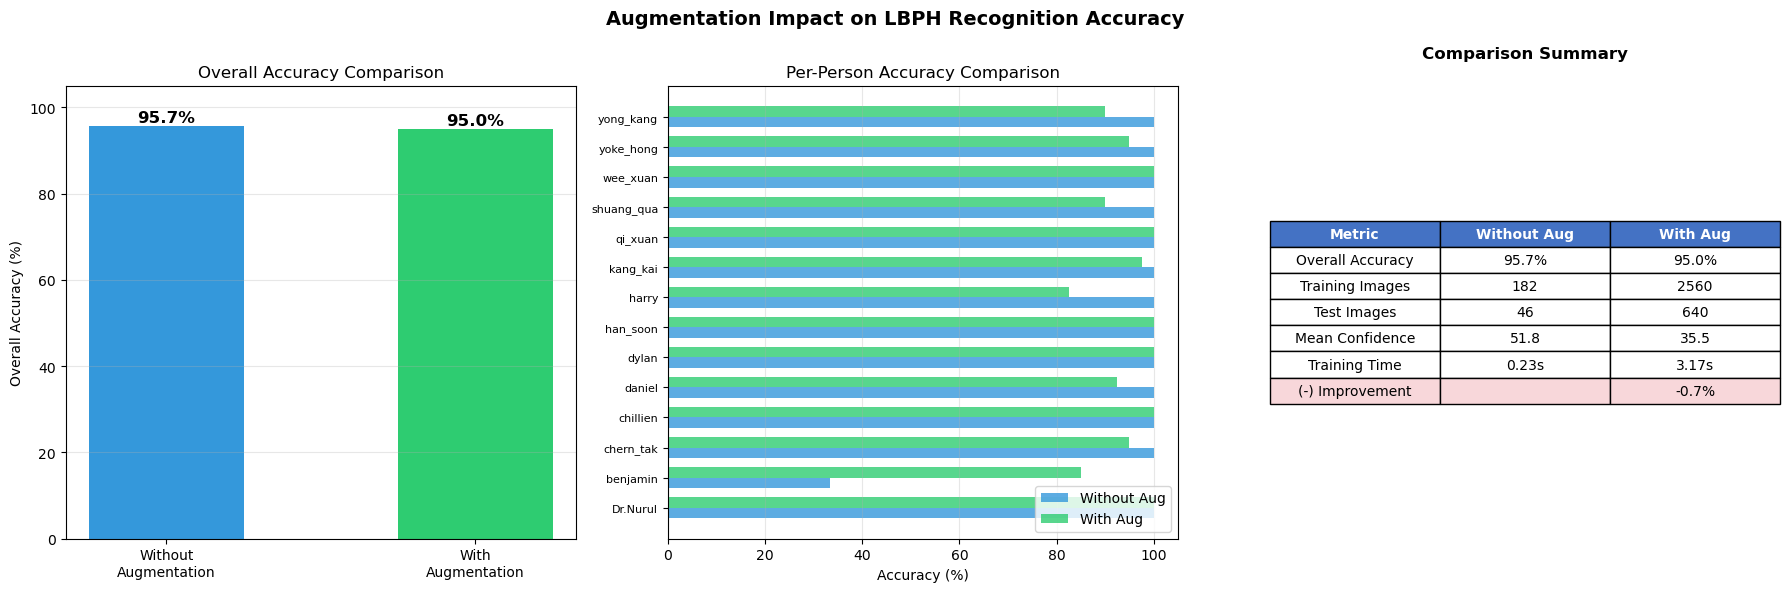


AUGMENTATION IMPACT SUMMARY
-------------------------------------------------------
  Without augmentation: 95.7% (182 training images)
  With augmentation:    95.0% (2560 training images)
  (-) Accuracy change: -0.7%
  Data expansion:    14.1x

  [X] No improvement. May need more diverse augmentation or more raw data.


In [28]:
# Compare model performance WITH vs WITHOUT augmentation
# This is the key evaluation showing augmentation's value
comparison_results = compare_augmentation_impact()